# Send-side quota enforcement in one-time-password software

**A reproduction notebook for the package survey and the concurrency measurement.
Artifact version `v4.7-r15`.**

An SMS one-time-password endpoint spends money every time it accepts a request. This
notebook reruns the SQLite main sweep, regenerates the reported analyses from the archived
request-level records, and provides commands for rerunning the survey and the complete
round-4 experiment suite. It does not itself rerun the survey or every Study 2 arm. The two
measurements behind the paper are:

1. **Study 1, the survey.** Of 42 sampled packages on the Python Package Index whose
   purpose is delivering a one-time or verification code, how many place any limit on
   *sending*, how many on *verifying*, and how many on both?
2. **Study 2, the measurement.** When the application writes the limit itself, does the
   limit survive requests that arrive at the same time, and which request interleavings
   produce which overruns?

The notebook runs in four parts. Part A shows the defect in a single cell with no server
at all. Part B starts the real service (FastAPI, SQLite, four worker processes), runs the
paper's harness against it over HTTP, keeps one event record per request, and evaluates
each implementation against the policy it actually enforces on its admission events.
Part C runs `regenerate.py`, the single script that recomputes every server-side Study 2
count and policy classification in the paper from the event records shipped in
`results/r4/` (and the survey's numbers from its frozen per-package audit), and displays
the tables and figures.
Part D reads the per-overrun classification and checks one overrun's window assignment
by hand from its event records.

**Nothing here sends a real message.** The provider is a local stub that sleeps for a
configurable interval and records the attempt. No telephone number in this notebook is
real, no external API is contacted, no package maintainer is contacted, and no production
system is involved.

| | |
|---|---|
| Part A | in-process, about ten seconds |
| Part B | the real service, SQLite main sweep only, at the paper's trial counts: about 15 minutes on two cores (`REDUCED = True` for about two) |
| Part C | `regenerate.py` over the shipped event records and the frozen survey audit, under a minute; no arm is re-run |
| Part D | reads `results/overrun_classification.csv` and one event record, instant |
| Other Study 2 arms | not run here; `reproduce.sh` re-runs all of them (about two hours) |
| Study 1 re-run | not run here; about 20 minutes and network access; commands at the end |

Table and figure numbers below follow manuscript v4.3 and its supplement (S numbers).

## 0. Setup

Run this notebook from inside a checkout of the artifact. It needs `fastapi`, `uvicorn`,
`httpx`, `pandas` and `matplotlib`; `requirements-lock.txt` pins the versions the reported
runs used.

In [1]:
import importlib.util
import inspect
import json
import os
import pathlib
import statistics
import sys
import tempfile
import threading
import time

ROOT = pathlib.Path.cwd()
while not (ROOT / "svc" / "app.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "svc" / "app.py").exists(), (
    "Could not find svc/app.py. Run this notebook from inside the artifact repository."
)
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

RESULTS = ROOT / "results"
missing = [m for m in ("fastapi", "uvicorn", "httpx", "pandas", "matplotlib")
           if importlib.util.find_spec(m) is None]

print("artifact version:", (ROOT / "VERSION").read_text().strip())
print("repository root :", ROOT)
print("python          :", sys.version.split()[0])
print("missing packages:", ", ".join(missing) if missing else "none")
print("shipped results :", len(list(RESULTS.glob("**/*.csv"))), "csv files,",
      len(list(RESULTS.glob("**/*.json"))), "json files")

artifact version: v4.7-r15
repository root : /home/claude/otpddos
python          : 3.11.15
missing packages: none
shipped results : 40 csv files, 16 json files


---
## 1. The six implementations of one policy

The declared policy throughout is the same: **at most three sends per phone number per
window.** Three implementations count records in a trailing (sliding) window of 3600
seconds; three keep a counter that resets at aligned boundaries (a fixed window). The two
are different policies, and the harness judges each implementation against its own.

Four of the six are structural analogues of code found in the packages surveyed in Study 1
(Table I in the paper states exactly what each source does and where the fixture differs);
two are remedies no sampled package uses. **The policy event** is the admission: the
completion of the implementation's own granting state update. For the two one-step
fixed-window implementations the database returns the window the admission counts in from
the granting statement itself (`RETURNING window_start, used`); for the read-modify-write
counter the recorded window is the one the request computed and wrote, because that pattern
decides in the application (`window_source` in each record says which); for the
sliding-window ones the admission timestamp is the value the implementation used in its own
check. The provider call comes
after the admission and its instant is never used to assign a window. Three do their bookkeeping in two steps, reading
the state and then writing it. Three decide in one step that the datastore serialises.

| Pattern | Steps | Policy | What the code does |
|---|---|---|---|
| `naive_count` | two | sliding | Count recent send records, compare against the limit, insert a record and send |
| `cache_get_set` | two | fixed | Read a counter, add one, write it back: the shape most cache-backed limiters take |
| `after_send` | two | sliding | Check the count, send the message, and only then record the send |
| `atomic_update` | one | fixed | Increment the counter only if it is below the limit, in one statement, and let the datastore report whether that happened |
| `immediate_txn` | one | sliding | Check and increment inside a single write transaction |
| `reserve_commit` | one | fixed | Claim the allowance with the atomic statement before calling the provider, and release it if the call fails |

`after_send` deserves a note, because it is the most *attractive* of the three two-step
ones. Incrementing after a successful send means a failed send does not consume the user's
allowance, which is a real and reasonable goal. The instinct is correct; the fix is to
release a reservation on failure, not to defer the claim.

Here is the source of all six, read directly from the service the experiments run against.

In [2]:
os.environ.update(
    OTP_DB=str(pathlib.Path(tempfile.mkdtemp(prefix="otpnb-")) / "demo.db"),
    OTP_LIMIT="3",
    OTP_WINDOW_S="3600",
    OTP_PROVIDER_MS="50",
    OTP_STRATEGY="naive_count",
)

import svc.app as S  # noqa: E402  (env must be set before import)

ORDER = ["naive_count", "cache_get_set", "after_send",
         "atomic_update", "immediate_txn", "reserve_commit"]
LABEL = {
    "naive_count": "Count-then-insert",
    "cache_get_set": "Read-modify-write counter",
    "after_send": "Increment after send",
    "atomic_update": "Conditional atomic update",
    "immediate_txn": "Guarded write transaction",
    "reserve_commit": "Reserve before send",
}

for name in ORDER:
    print("=" * 74)
    print(f"{name}   ({LABEL[name]})")
    print("=" * 74)
    print(inspect.getsource(S.STRATEGIES[name]))

naive_count   (Count-then-insert)
def s_naive_count(phone):
    """Count rows, compare, then insert. No transaction around the pair."""
    ev = new_event(phone)
    now = time.time()
    c = conn()
    used = c.execute(
        "SELECT COUNT(*) FROM attempts WHERE phone=? AND ts>=?",
        (phone, now - WINDOW_S),
    ).fetchone()[0]
    ev["t_read"], ev["observed"] = time.time(), used
    if used >= LIMIT:
        c.close()
        ev["t_decide"] = time.time()
        return finish(ev, "refuse", "over_quota")
    ev["t_decide"] = time.time()
    cur = c.execute("INSERT INTO attempts(phone, ts) VALUES (?,?)", (phone, now))
    ev["t_write"] = time.time()
    ev["record_id"] = cur.lastrowid          # database-assigned insertion order
    c.close()
    admitted_sliding(ev, now, used + 1)      # `now` is the timestamp the check used
    provider_send(phone, ev)
    return finish(ev, "admit", "sent")

cache_get_set   (Read-modify-write counter)
def s_cache_get_set(phone):
    """Read c

And the provider stub, which is the only thing in the service that would cost money in the
real world. Every request also writes one event record (`record_event`) after it finishes;
that record, not the provider row, is what the policy is evaluated on.

In [3]:
print(inspect.getsource(S.provider_send))
print(inspect.getsource(S.record_event))
print("declared limit :", S.LIMIT)
print("window         :", S.WINDOW_S, "s")
print("provider stub  :", S.PROVIDER_MS, "ms")

def provider_send(phone: str, ev) -> str:
    """Stand-in for the aggregator API call. Records one provider-call attempt.

    The start and end instants are recorded in the event; the provider_sends
    row keeps its own instant so the two records can be cross-checked.
    """
    ev["t_provider_start"] = time.time()
    if PROVIDER_MS > 0:
        time.sleep(PROVIDER_MS / 1000.0)
    mid = uuid.uuid4().hex
    c = conn()
    c.execute(
        "INSERT INTO provider_sends(phone, message_id, ts) VALUES (?,?,?)",
        (phone, mid, time.time()),
    )
    c.close()
    ev["t_provider_end"] = time.time()
    ev["message_id"] = mid
    return mid

def record_event(ev):
    """Append one event record to this worker's log, after the request."""
    global _event_file
    if _event_file is None:
        os.makedirs(EVENT_DIR, exist_ok=True)
        _event_file = open(os.path.join(EVENT_DIR, f"events-{os.getpid()}.jsonl"), "a")
    ev["pid"] = os.getpid()
    ev["strategy"] = STRATEGY
    e

---
## Part A: the race, in one cell

No server, no HTTP, no worker processes. We call the six quota functions directly from
threads that are released at the same instant by a barrier, and then count how many calls
reached the provider stub.

This is the shortest honest demonstration of the defect. It takes about ten seconds.

In [4]:
S.init_db()


def reset():
    c = S.conn()
    for t in ("attempts", "counters", "provider_sends", "reservations"):
        c.execute(f"DELETE FROM {t}")
    c.close()


def provider_calls(phone):
    c = S.conn()
    n = c.execute("SELECT COUNT(*) FROM provider_sends WHERE phone=?",
                  (phone,)).fetchone()[0]
    c.close()
    return n


ERRORS = []


def burst_inprocess(fn, phone, k):
    # Release k calls to fn at the same instant; return recorded provider calls.
    # Exceptions are recorded, never swallowed: a failed client observation is
    # not the same thing as no provider action.
    gate = threading.Barrier(k)

    def worker():
        gate.wait()
        try:
            fn(phone)
        except Exception as e:
            ERRORS.append(type(e).__name__)

    threads = [threading.Thread(target=worker) for _ in range(k)]
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    return provider_calls(phone)


K, TRIALS = 8, 5
print(f"declared limit = {S.LIMIT}    simultaneous requests = {K}    trials = {TRIALS}\n")
print(f"{'pattern':<28}{'provider calls per trial':<30}{'worst'}")
print("-" * 68)
for name in ORDER:
    got = []
    for t in range(TRIALS):
        phone = f"+1000{name[:4]}{t}"
        reset()
        got.append(burst_inprocess(S.STRATEGIES[name], phone, K))
    print(f"{LABEL[name]:<28}{str(got):<30}{max(got)}")
print(f"\nexceptions raised across all calls: {len(ERRORS)}"
      + (f"  {sorted(set(ERRORS))}" if ERRORS else ""))

declared limit = 3    simultaneous requests = 8    trials = 5

pattern                     provider calls per trial      worst
--------------------------------------------------------------------


Count-then-insert           [8, 8, 8, 8, 8]               8


Read-modify-write counter   [8, 8, 8, 8, 8]               8


Increment after send        [8, 8, 8, 8, 8]               8


Conditional atomic update   [3, 3, 3, 3, 3]               3


Guarded write transaction   [3, 3, 3, 3, 3]               3


Reserve before send         [3, 3, 3, 3, 3]               3

exceptions raised across all calls: 0


The three two-step patterns overshoot; the three one-step patterns do not. Every one of
those calls returned normally: the two-step implementations did not fail, they *succeeded*
more times than the policy allows.

Part A is deliberately artificial in one respect: it calls the quota functions in-process,
which is not how anybody deploys an OTP endpoint. Part B removes that objection.

---
## Part B: the real service, four worker processes, over HTTP

This is the configuration the paper measures: `uvicorn` with `--workers 4` in front of the
FastAPI app, SQLite in write-ahead-logging mode behind it, and requests arriving as real
HTTP POSTs from a thread barrier in a separate process.

Nothing in the service is instrumented to widen a race. There is no injected sleep inside a
critical section and no lock removed for effect. The only tunable is the provider stub's
latency, and Part C shows the result does not depend on it.

The harness is `study/run_experiments.py`. After every burst it fetches one event record
per request from the service (`GET /otp/events`) and evaluates the declared policy on the
admission events with `study/policy.py`: the largest number of admissions in any window
identifier for the fixed-window implementations, the largest number in any trailing
interval for the sliding-window ones. Both the raw total and the policy-relevant maximum
are kept, because a burst that straddles a fixed-window boundary can legitimately exceed
the limit in total while exceeding it in no window. That distinction is the subject of
Part D.

In [5]:
os.environ["EXP_PORT"] = "8131"
os.environ["EXP_DB"] = str(pathlib.Path(tempfile.mkdtemp(prefix="otpnb-")) / "exp.db")
os.environ["EXP_EVENT_DIR"] = os.environ["EXP_DB"] + ".events"

import study.run_experiments as RC  # noqa: E402
import study.policy as POL  # noqa: E402

print("harness endpoint:", RC.BASE)
print("policy per implementation:", RC.POLICY)
print()
print(inspect.getsource(RC.burst))
print(inspect.getsource(POL.evaluate))

harness endpoint: http://127.0.0.1:8131
policy per implementation: {'naive_count': 'sliding', 'after_send': 'sliding', 'immediate_txn': 'sliding', 'cache_get_set': 'fixed', 'atomic_update': 'fixed', 'reserve_commit': 'fixed'}

def burst(phone, k, timeout=120.0):
    """Release k requests simultaneously. Returns one outcome string each."""
    barrier = threading.Barrier(k)
    out = [None] * k

    def worker(i):
        with httpx.Client(timeout=timeout) as c:
            barrier.wait()
            try:
                r = c.post(f"{BASE}/otp/request", json={"phone": phone})
                out[i] = r.json().get("status", f"http_{r.status_code}")
            except Exception as e:          # recorded, never swallowed
                out[i] = f"error:{type(e).__name__}"

    ts = [threading.Thread(target=worker, args=(i,)) for i in range(k)]
    for t in ts:
        t.start()
    for t in ts:
        t.join()
    return out

def evaluate(events, limit, window_s, policy):
    admits = [

### Running the sweep

`REDUCED = True` runs 3 trials per cell, which takes about two minutes and is enough to see
the effect. The default, `False`, runs the paper's 30 trials per cell: 1 080 trials, about
15 minutes on two cores. Every request's event record is kept in `events`.

In [6]:
# Full reproduction is the default: this is the paper's trial count.
# Set REDUCED = True for a two-minute run that shows the effect but does not
# reproduce the published figures.
REDUCED = False
TRIALS = 3 if REDUCED else 30
KS = [1, 2, 4, 8, 16, 32]

rows, events = [], []
t0 = time.time()
for name in ORDER:
    proc = RC.start_server(name, 3, 50.0, "sqlite", 4)
    try:
        for k in KS:
            for trial in range(TRIALS):
                phone = f"+1999{name[:4]}{k}{trial}"
                RC.httpx.post(f"{RC.BASE}/admin/reset", timeout=30.0)
                replies = RC.burst(phone, k)
                evs, lim, win, pol = RC.events_for(phone)
                ev = POL.evaluate(evs, lim, win, pol)
                for e in evs:
                    # the service stamps its own strategy name on every
                    # record; the notebook's identity fields win, as in the
                    # harness
                    events.append({**e, "strategy": name, "k": k, "trial": trial})
                rows.append(dict(
                    strategy=name, k=k, trial=trial,
                    admits=ev["admits"], provider_calls=ev["provider_calls"],
                    requests_logged=ev["requests"], max_in_window=ev["max_per_policy"],
                    policy_overrun=ev["policy_overrun"], windows=ev["windows_touched"],
                    accepted=sum(1 for r in replies if r == "sent"),
                    rejected=sum(1 for r in replies if r == "rejected"),
                    errors=sum(1 for r in replies if str(r).startswith("error")),
                ))
    finally:
        RC.stop_server(proc)
    print(f"  {LABEL[name]:<28} done   ({time.time() - t0:5.0f}s elapsed)")

print(f"\n{len(rows)} trials, {len(events)} event records, in {time.time() - t0:.0f}s; "
      f"client errors: {sum(r['errors'] for r in rows)}; "
      f"trials where provider calls != admissions: {sum(r['provider_calls'] != r['admits'] for r in rows)}")

  Count-then-insert            done   (  136s elapsed)


  Read-modify-write counter    done   (  275s elapsed)


  Increment after send         done   (  416s elapsed)


  Conditional atomic update    done   (  551s elapsed)


  Guarded write transaction    done   (  684s elapsed)


  Reserve before send          done   (  818s elapsed)

1080 trials, 11340 event records, in 818s; client errors: 0; trials where provider calls != admissions: 0


In [7]:
import pandas as pd  # noqa: E402

run = pd.DataFrame(rows)


def sweep_table(df, kcol="k", vcol="admits", limit=3):
    out = []
    for s in ORDER:
        d = df[df.strategy == s]
        r = {"pattern": LABEL[s]}
        for k in sorted(df[kcol].unique()):
            v = d[d[kcol] == k][vcol]
            r[f"k={k}"] = f"{v.median():g}/{int(v.max())}"
        r["over (total)"] = int((d[vcol] > limit).sum())
        r["policy violations"] = int((d["policy_overrun"] > 0).sum())
        r["worst"] = f"{d[vcol].max() / limit:.1f}x"
        out.append(r)
    return pd.DataFrame(out).set_index("pattern")


print("admissions against a declared limit of 3: median / maximum per cell\n")
sweep_table(run)

admissions against a declared limit of 3: median / maximum per cell



,k=1,k=2,k=4,k=8,k=16,k=32,over (total),policy violations,worst
pattern,,,,,,,,,
Count-then-insert,1/1,2/2,4/4,8/8,11/16,5/32,110,110,10.7x
Read-modify-write counter,1/1,2/2,4/4,8/8,15.5/16,20.5/32,119,119,10.7x
Increment after send,1/1,2/2,4/4,8/8,16/16,32/32,120,120,10.7x
Conditional atomic update,1/1,2/2,3/3,3/3,3/3,3/3,0,0,1.0x
Guarded write transaction,1/1,2/2,3/3,3/3,3/3,3/3,0,0,1.0x
Reserve before send,1/1,2/2,3/3,3/3,3/3,3/3,0,0,1.0x


Two things to read out of that table.

At `k=1` and `k=2` every implementation is correct. The defect is invisible to any test
that does not overlap requests, which is most test suites, because issuing requests in a
loop and asserting that the fourth is rejected is the obvious way to test a rate limit, and
it passes against all six.

Further up the range, the two-step implementations stop being merely wrong and start
matching the request count: whatever the attacker sends, the service delivers. The reply to
every one of those requests was a success. The two "over" columns agree here because a
one-hour window is almost never straddled by a burst; Part D shows what happens when it is.

In [8]:
# one event record, so the fields are visible
print(json.dumps(next(e for e in events if e["decision"] == "admit" and e["strategy"] == "atomic_update"), indent=1))

{
 "rid": "aa0afa3aa4c04eb8ac8a7a9e1a7f23da",
 "phone": "+1999atom10",
 "t_recv": 1791479783.7903793,
 "t_read": 1791479783.7963483,
 "t_decide": 1791479783.7967048,
 "t_write": 1791479783.7967048,
 "window_id": 1791478800.0,
 "policy_ts": 1791478800.0,
 "counter_after": 1,
 "window_source": "returning",
 "t_provider_start": 1791479783.797157,
 "t_provider_end": 1791479783.8487403,
 "message_id": "175fd07c0ec341d99591009039dab957",
 "decision": "admit",
 "t_done": 1791479783.848744,
 "pid": 31289,
 "strategy": "atomic_update",
 "policy": "fixed",
 "limit": 3,
 "window_s": 3600,
 "k": 1,
 "trial": 0
}


---
## Part C: every number in the paper, regenerated from the event records

`regenerate.py` reads the event records in `results/r4/` and the per-package audit, evaluates
the policy on the admission events, derives every per-trial summary and checks it against the
harness's own CSV (it stops if they disagree), and recomputes every count, median, maximum,
quartile, exceedance count, Wilson interval and cross-tabulation in the paper into
`results/paper_numbers.json`. It also writes `results/overrun_classification.csv`. (The
SHA-256 manifest is written separately by `study/manifest.py`, last, when the archive is
assembled.) `study/paper_tables.py` then writes the LaTeX bodies of the result tables
from that file, so no measured number in a result table is typed by hand.

In [9]:
import regenerate as RG  # noqa: E402

RG.main([])   # [] : do not parse the kernel's own command line
P = json.load(open(RESULTS / "paper_numbers.json"))
S1, S2, OV, H = P["study1"], P["study2"], P["overruns"], P["historical"]
print("\nartifact version:", P["version"])
print("round-4 arms:", S2["arms"], "total", S2["arms_total"])
print("historical arms total:", H["arms_total"])

# Every reported number, regenerated  (artifact v4.7-r15)

## Study 1

- index_projects: 896086
- name_matches: 991
- metadata_kept: 761
- downloaded_ok: 756
- detector_flagged: 61
- excluded_by_hand: 19
- retained: 42
- send_control_evidence_levels: {'delegated_provider': 3, 'none_in_package': 28, 'in_package_framework_throttle': 3, 'in_package_delivery_path': 7, 'helper_not_wired': 1}
- send_control_yes: 13
- send_control_yes_pct: 31.0
- send_control_yes_ci_pct: [19.1, 46.0]
- send_control_in_package: 10
- send_control_in_package_pct: 23.8
- send_control_in_package_ci_pct: [13.5, 38.5]
- send_control_delegated_provider: 3
- send_control_helper_not_wired: 1
- send_control_none_in_package: 28
- send_control_no: 29
- send_control_no_pct: 69.0
- verify_control_yes: 17
- both_controls: 7
- send_only: 6
- verify_only: 10
- neither: 19
- crosstab: {'send_yes_verify_yes': 7, 'send_yes_verify_no': 6, 'send_no_verify_yes': 10, 'send_no_verify_no': 19}
- verify_only_packages: ['LinOTP', 'django

### Table II of the paper and Table S5 of the supplement: every experimental arm

In [10]:
arms = pd.Series(S2["arms"], name="round-4 trials")
arms.loc["total"] = S2["arms_total"]
display(arms.to_frame())
hist = pd.Series(H["arms"], name="historical trials (rounds 1-3)")
hist.loc["total"] = H["arms_total"]
hist.to_frame()

,round-4 trials
main_sqlite,1080
main_postgres,1080
sequential,180
latency,720
workers,720
limits,360
postgres_pooled,360
boundary_sqlite,180
boundary_postgres,180
package_exec,360


,historical trials (rounds 1-3)
main_sqlite_r1,1080
sequential_r1,180
latency_r1,480
latency_r2,240
main_postgres_r2,1080
postgres_pooled_r2,240
main_sqlite_randomised_r2,1080
workers_r2,720
limits_r2,360
instrumented_sqlite_r2,90


### Table V: admissions under concurrent load (SQLite main sweep)

Each cell is median / maximum over 30 trials with the number of trials exceeding the limit in
total; "PV" is the number whose declared policy was violated per window.

In [11]:
def paper_sweep(name):
    ks = S2["concurrency_levels"]
    out = []
    for s in ORDER:
        r = {"pattern": LABEL[s]}
        for k in ks:
            c = S2[name][f"{s}|{k}"]
            r[f"k={k}"] = f"{c['median']:g}/{c['max']} ({c['over_total']})"
        tot = S2[name + "_summary"][s]
        r["over"] = tot["over_total"]
        r["PV"] = tot["policy_violations"]
        r["worst"] = f"{tot['worst_amplification']}x"
        out.append(r)
    return pd.DataFrame(out).set_index("pattern")


paper_sweep("main_sqlite")

,k=1,k=2,k=4,k=8,k=16,k=32,over,PV,worst
pattern,,,,,,,,,
Count-then-insert,1/1 (0),2/2 (0),4/4 (30),8/8 (30),10/16 (29),6.5/27 (24),113,113,9.0x
Read-modify-write counter,1/1 (0),2/2 (0),4/4 (30),8/8 (30),16/16 (29),18.5/32 (29),118,118,10.7x
Increment after send,1/1 (0),2/2 (0),4/4 (30),8/8 (30),16/16 (30),32/32 (30),120,120,10.7x
Conditional atomic update,1/1 (0),2/2 (0),3/3 (0),3/3 (0),3/3 (0),3/3 (0),0,0,1.0x
Guarded write transaction,1/1 (0),2/2 (0),3/3 (0),3/3 (0),3/3 (0),3/3 (0),0,0,1.0x
Reserve before send,1/1 (0),2/2 (0),3/3 (0),3/3 (0),3/3 (0),3/3 (0),0,0,1.0x


### Table S8 (supplement): quartiles of the cells whose trials are not all alike, with Wilson intervals

In [12]:
out = []
for name, ds in (("main_sqlite", "SQLite"), ("main_postgres", "PostgreSQL")):
    for s in ORDER:
        for k in S2["concurrency_levels"]:
            c = S2[name][f"{s}|{k}"]
            if c["min"] != c["max"]:
                out.append(dict(datastore=ds, pattern=LABEL[s], k=k, min=c["min"],
                                Q1=c["q1"], median=c["median"], Q3=c["q3"], max=c["max"],
                                over=c["over_total"], over_ci_pct=c["over_total_ci_pct"]))
pd.DataFrame(out)

,datastore,pattern,k,min,Q1,median,Q3,max,over,over_ci_pct
0,SQLite,Count-then-insert,8,5,8.00,8.0,8.00,8,30,"[88.6, 100.0]"
1,SQLite,Count-then-insert,16,3,6.00,10.0,16.00,16,29,"[83.3, 99.4]"
2,SQLite,Count-then-insert,32,3,4.00,6.5,13.75,27,24,"[62.7, 90.5]"
3,SQLite,Read-modify-write counter,8,6,8.00,8.0,8.00,8,30,"[88.6, 100.0]"
4,SQLite,Read-modify-write counter,16,3,14.50,16.0,16.00,16,29,"[83.3, 99.4]"
5,SQLite,Read-modify-write counter,32,3,6.75,18.5,27.00,32,29,"[83.3, 99.4]"
6,PostgreSQL,Count-then-insert,4,3,3.00,4.0,4.00,4,20,"[48.8, 80.8]"
7,PostgreSQL,Count-then-insert,8,3,3.00,4.0,4.25,5,20,"[48.8, 80.8]"
8,PostgreSQL,Count-then-insert,16,3,3.00,4.0,5.00,12,19,"[45.5, 78.1]"
9,PostgreSQL,Count-then-insert,32,3,3.00,4.0,5.00,7,22,"[55.6, 85.8]"


### Figure S4 (supplement): median admissions against simultaneous requests

The three one-step implementations have identical medians at every level, min(k, 3), and are
drawn on the same points with markers of different sizes so that each remains visible.

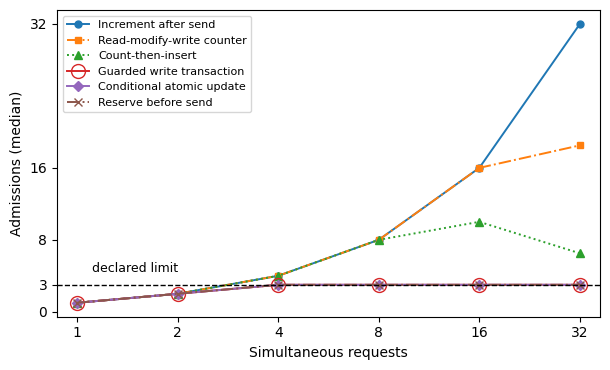

checked: the three one-step patterns are identical at every level, and each admits
        min(requests, declared limit), never more, in the main sweep.


In [13]:
import matplotlib.pyplot as plt  # noqa: E402

LIMIT = S2["declared_limit"]
ks = S2["concurrency_levels"]
med = {s: [S2["main_sqlite"][f"{s}|{k}"]["median"] for k in ks] for s in ORDER}

fig, ax = plt.subplots(figsize=(6.2, 3.8))
styles = [("after_send", "-", "o", 5, "Increment after send"),
          ("cache_get_set", "-.", "s", 5, "Read-modify-write counter"),
          ("naive_count", ":", "^", 6, "Count-then-insert"),
          ("immediate_txn", "-", "o", 10, "Guarded write transaction"),
          ("atomic_update", "-", "D", 5, "Conditional atomic update"),
          ("reserve_commit", "-.", "x", 6, "Reserve before send")]
for key, ls, mk, ms, lab in styles:
    kw = dict(markerfacecolor="none") if mk == "o" and ms == 10 else {}
    ax.plot(range(len(ks)), med[key], ls, marker=mk, label=lab, linewidth=1.4,
            markersize=ms, **kw)
ax.axhline(LIMIT, color="black", linestyle="--", linewidth=1)
ax.annotate("declared limit", xy=(0.15, LIMIT), xytext=(0.15, LIMIT + 1.4), fontsize=9)
ax.set_xticks(range(len(ks)))
ax.set_xticklabels(ks)
ax.set_yticks([0, LIMIT, 8, 16, 32])
ax.set_xlabel("Simultaneous requests")
ax.set_ylabel("Admissions (median)")
ax.legend(fontsize=8, loc="upper left")
ax.margins(x=0.04)
fig.tight_layout()
plt.show()

expected = [min(k, LIMIT) for k in ks]
for s in ("atomic_update", "immediate_txn", "reserve_commit"):
    assert med[s] == expected, f"{s} did not hold the declared limit"
print("checked: the three one-step patterns are identical at every level, and each admits")
print("        min(requests, declared limit), never more, in the main sweep.")

### Figure S5 (supplement): the same requests, overlapped and sequential

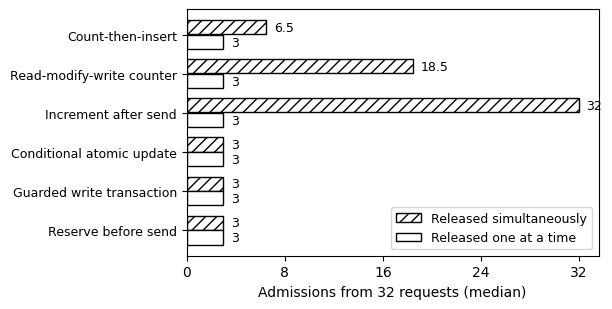

sequential control, every cell exactly at the limit: True


In [14]:
con32 = {s: S2["main_sqlite"][f"{s}|32"]["median"] for s in ORDER}
seq32 = {s: S2["sequential"][f"{s}|32"]["median"] for s in ORDER}

rowlab, a, b = [], [], []
for s in reversed(ORDER):
    rowlab.append(LABEL[s])
    a.append(con32[s])
    b.append(seq32[s])

y = range(len(rowlab))
fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.barh([i + 0.19 for i in y], a, height=0.36, hatch="///",
        facecolor="white", edgecolor="black", label="Released simultaneously")
ax.barh([i - 0.19 for i in y], b, height=0.36,
        facecolor="white", edgecolor="black", label="Released one at a time")
for i, (va, vb) in enumerate(zip(a, b)):
    ax.text(va + 0.6, i + 0.19, f"{va:g}", va="center", fontsize=9)
    ax.text(vb + 0.6, i - 0.19, f"{vb:g}", va="center", fontsize=9)
ax.set_yticks(list(y))
ax.set_yticklabels(rowlab, fontsize=9)
ax.set_xticks([0, 8, 16, 24, 32])
ax.set_xlabel("Admissions from 32 requests (median)")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
plt.show()

print("sequential control, every cell exactly at the limit:", bool(S2["sequential_all_equal_limit"]))

### Table S9 (supplement): is the race just the slow provider call?

In [15]:
out = []
for s in ORDER:
    r = {"pattern": LABEL[s]}
    for ms in (0.0, 10.0, 50.0, 200.0):
        c = S2["latency"][f"{s}|{ms}"]
        r[f"{ms:g} ms"] = f"{c['median']:g} ({c['over_total']}/{c['n']})"
    out.append(r)
print("median admissions at 8 simultaneous requests "
      "(trials exceeding the declared limit of 3 in brackets)\n")
pd.DataFrame(out).set_index("pattern")

median admissions at 8 simultaneous requests (trials exceeding the declared limit of 3 in brackets)



,0 ms,10 ms,50 ms,200 ms
pattern,,,,
Count-then-insert,8 (30/30),8 (27/30),8 (28/30),8 (29/30)
Read-modify-write counter,8 (30/30),8 (30/30),8 (30/30),8 (30/30)
Increment after send,8 (30/30),8 (30/30),8 (30/30),8 (30/30)
Conditional atomic update,3 (0/30),3 (0/30),3 (0/30),3 (0/30)
Guarded write transaction,3 (0/30),3 (0/30),3 (0/30),3 (0/30)
Reserve before send,3 (0/30),3 (0/30),3 (0/30),3 (0/30)


### Table VI: the same sweep on PostgreSQL 16, and the pooled arm

In [16]:
print("PostgreSQL 16, one connection per request:")
display(paper_sweep("main_postgres"))
print("\nPostgreSQL 16, pool of eight (k = 8 and 32):")
pd.DataFrame({k: {kk: v[kk] for kk in ("median", "max", "over_total", "policy_violations")}
              for k, v in S2["postgres_pooled"].items()}).T

PostgreSQL 16, one connection per request:


,k=1,k=2,k=4,k=8,k=16,k=32,over,PV,worst
pattern,,,,,,,,,
Count-then-insert,1/1 (0),2/2 (0),4/4 (20),4/5 (20),4/12 (19),4/7 (22),81,81,4.0x
Read-modify-write counter,1/1 (0),2/2 (0),4/4 (28),6/8 (29),5/16 (27),5/13 (28),112,112,5.3x
Increment after send,1/1 (0),2/2 (0),4/4 (30),8/8 (30),16/16 (30),32/32 (30),120,120,10.7x
Conditional atomic update,1/1 (0),2/2 (0),3/3 (0),3/3 (0),3/3 (0),3/3 (0),0,0,1.0x
Guarded write transaction,1/1 (0),2/2 (0),3/3 (0),3/3 (0),3/3 (0),3/3 (0),0,0,1.0x
Reserve before send,1/1 (0),2/2 (0),3/3 (0),3/3 (0),3/3 (0),3/3 (0),0,0,1.0x



PostgreSQL 16, pool of eight (k = 8 and 32):


,median,max,over_total,policy_violations
naive_count|8,5.0,8.0,26.0,26.0
naive_count|32,4.0,7.0,16.0,16.0
cache_get_set|8,8.0,8.0,30.0,30.0
cache_get_set|32,9.5,26.0,28.0,28.0
after_send|8,8.0,8.0,30.0,30.0
after_send|32,32.0,32.0,30.0,30.0
atomic_update|8,3.0,3.0,0.0,0.0
atomic_update|32,3.0,3.0,0.0,0.0
immediate_txn|8,3.0,3.0,0.0,0.0
immediate_txn|32,3.0,3.0,0.0,0.0


### Sensitivity arms: workers and declared limit (Section V-J)

In [17]:
print("worker count (strategy|workers|k):")
display(pd.DataFrame({k: {kk: v[kk] for kk in ("median", "max", "over_total", "policy_violations")}
                      for k, v in S2["workers"].items()}).T)
print("\ndeclared limit at k=16 (strategy|limit):")
pd.DataFrame({k: {kk: v[kk] for kk in ("median", "max", "over_total", "policy_violations")}
              for k, v in S2["limits"].items()}).T

worker count (strategy|workers|k):


,median,max,over_total,policy_violations
naive_count|1|8,8.0,8.0,19.0,19.0
naive_count|1|32,4.5,21.0,14.0,14.0
naive_count|2|8,8.0,8.0,20.0,20.0
naive_count|2|32,5.5,21.0,15.0,15.0
naive_count|8|8,8.0,8.0,20.0,20.0
naive_count|8|32,9.0,26.0,16.0,16.0
cache_get_set|1|8,8.0,8.0,20.0,20.0
cache_get_set|1|32,8.0,32.0,18.0,18.0
cache_get_set|2|8,8.0,8.0,20.0,20.0
cache_get_set|2|32,7.0,30.0,20.0,20.0



declared limit at k=16 (strategy|limit):


,median,max,over_total,policy_violations
naive_count|1,2.5,16.0,13.0,13.0
naive_count|5,15.5,16.0,19.0,19.0
naive_count|10,16.0,16.0,20.0,20.0
cache_get_set|1,3.5,14.0,15.0,15.0
cache_get_set|5,16.0,16.0,20.0,20.0
cache_get_set|10,16.0,16.0,20.0,20.0
after_send|1,16.0,16.0,20.0,20.0
after_send|5,16.0,16.0,20.0,20.0
after_send|10,16.0,16.0,20.0,20.0
atomic_update|1,1.0,1.0,0.0,0.0


### Figure 3 and Table S10: a surveyed package executed as shipped

`study/run_package_exec.py` drives `django-otp` 1.7.3's own `EmailDevice.generate_challenge`
through the same barrier protocol, with a counting e-mail backend that opens no connection,
and records per-call events: the instant each thread loaded its instance, the cooldown
timestamp that instance carried, and the instants of the `send_mail` calls it made.

In [18]:
out = []
for mode in ("sequential", "concurrent"):
    r = {"mode": mode}
    for k in (1, 2, 4, 8, 16, 32):
        c = S2["package_exec"][f"{mode}|k={k}"]
        r[f"k={k}"] = f"{c['median']:g}/{c['max']} ({c['over_limit']})"
    out.append(r)
print(f"deliveries attempted, median/max (trials over the limit of 1); "
      f"concurrent over, all k: {S2['package_exec_concurrent_over_all_k']} of "
      f"{S2['package_exec_concurrent_trials_all_k']}; k>=2: "
      f"{S2['package_exec_concurrent_over_k_ge_2']} of "
      f"{S2['package_exec_concurrent_trials_k_ge_2']}; errors {S2['package_exec_errors']}; "
      f"excess admissions {S2['package_exec_excess_admissions']}, of which loaded a null cooldown: "
      f"{S2['package_exec_excess_admissions_loaded_null_cooldown']}\n")
pd.DataFrame(out).set_index("mode")

deliveries attempted, median/max (trials over the limit of 1); concurrent over, all k: 110 of 180; k>=2: 110 of 150; errors 0; excess admissions 378, of which loaded a null cooldown: 378



,k=1,k=2,k=4,k=8,k=16,k=32
mode,,,,,,
sequential,1/1 (0),1/1 (0),1/1 (0),1/1 (0),1/1 (0),1/1 (0)
concurrent,1/1 (0),2/2 (22),2/4 (24),2/7 (17),5/11 (25),5.5/16 (22)


### Table S11 (supplement): the race window, measured (admitted requests only)

The window is the time from reading the quota state to writing it back, over admitted
requests. For the conditional atomic update the same two instants bracket the single
granting statement, so that column is the statement's execution time and not a race window;
the execution time of refused statements is reported separately. All instants are
application-observed.

In [19]:
out = []
for key, ds in (("main_sqlite", "SQLite"), ("main_postgres", "PostgreSQL"), ("postgres_pooled", "PostgreSQL, pooled")):
    for k, v in S2[key + "_timing"].items():
        s, kk = k.split("|")
        if int(kk) in (2, 8, 32):
            out.append(dict(datastore=ds, pattern=LABEL[s], k=int(kk),
                            admitted_window_ms_median=v["admitted_read_to_write_ms_median"],
                            admitted_window_ms_p90=v["admitted_read_to_write_ms_p90"],
                            refused_statement_ms_median=v["refused_statement_ms_median"],
                            spread_ms_median=v["arrival_spread_ms_median"],
                            spread_ms_max=v["arrival_spread_ms_max"]))
pd.DataFrame(out)

,datastore,pattern,k,admitted_window_ms_median,admitted_window_ms_p90,refused_statement_ms_median,spread_ms_median,spread_ms_max
0,SQLite,Count-then-insert,2,1.89,4.03,NaN,0.70,1.95
1,SQLite,Count-then-insert,8,4.22,19.62,NaN,5.97,13.48
2,SQLite,Count-then-insert,32,11.77,57.32,NaN,40.30,119.92
3,SQLite,Read-modify-write counter,2,1.51,3.32,NaN,0.54,29.99
4,SQLite,Read-modify-write counter,8,3.09,5.57,NaN,5.82,10.35
5,SQLite,Read-modify-write counter,32,4.51,19.62,NaN,34.24,59.84
6,SQLite,Increment after send,2,55.02,57.69,NaN,0.75,1.85
7,SQLite,Increment after send,8,60.55,87.16,NaN,5.19,9.66
8,SQLite,Increment after send,32,86.03,159.97,NaN,26.48,34.36
9,SQLite,Conditional atomic update,2,0.48,1.02,NaN,0.75,3.01


### Table VII (and Table S12 in full): which interleavings produced which overruns

Primary evidence is database-visible state: the value each request's own read returned
(`observed`) and the counter value each admitted request wrote (`counter_after`). An admission
beyond the limit that observed a value below the limit read stale state; admissions minus
the largest counter value ever written is a lower bound on lost updates. The
application-observed instant comparisons are proxies for the database's order.

In [20]:
out = []
for arm, ds in (("main_sqlite", "SQLite"), ("main_postgres", "PostgreSQL"), ("postgres_pooled", "PostgreSQL, pooled")):
    for key, x in S2[arm + "_interleaving"].items():
        s, kk = key.split("|")
        if int(kk) in (8, 32):
            out.append(dict(datastore=ds, pattern=LABEL[s], k=int(kk),
                            overrun_trials=x["overrun_trials"], excess=x["excess_admissions"],
                            excess_observed_below_limit=x["excess_observed_below_limit"],
                            lost_updates_lower_bound=x.get("lost_updates_lower_bound", ""),
                            trials_with_lost_update=x.get("trials_with_lost_update", ""),
                            excess_read_before_T3_app=x.get("excess_read_before_Lth_write_app", ""),
                            refused_issued_before_T3_app=x.get("refused_issued_before_Lth_write_app", ""),
                            refused=x["refused"],
                            first_arrival_to_T3_ms=x.get("first_arrival_to_Lth_write_ms_median", ""),
                            arrival_spread_ms=x.get("arrival_spread_ms_median", ""),
                            read_spread_ms=x.get("read_spread_ms_median", "")))
pd.DataFrame(out)

,datastore,pattern,k,overrun_trials,excess,excess_observed_below_limit,lost_updates_lower_bound,trials_with_lost_update,excess_read_before_T3_app,refused_issued_before_T3_app,refused,first_arrival_to_T3_ms,arrival_spread_ms,read_spread_ms
0,SQLite,Count-then-insert,8,30,145,145,,,145,0,5,7.54,5.97,5.47
1,SQLite,Count-then-insert,32,24,175,175,,,173,24,695,16.79,40.30,41.02
2,SQLite,Read-modify-write counter,8,30,147,147,172,30,105,0,3,5.78,5.82,5.75
3,SQLite,Read-modify-write counter,32,29,425,425,425,29,160,10,445,14.98,34.24,34.98
4,SQLite,Increment after send,8,30,150,150,,,150,0,0,60.09,5.19,5.54
5,SQLite,Increment after send,32,30,870,870,,,870,0,0,65.36,26.48,26.01
6,SQLite,Conditional atomic update,8,0,0,0,,,0,12,150,8.86,6.55,8.10
7,SQLite,Conditional atomic update,32,0,0,0,,,0,95,870,16.47,46.11,43.30
8,SQLite,Guarded write transaction,8,0,0,0,,,0,0,150,7.90,6.14,12.84
9,SQLite,Guarded write transaction,32,0,0,0,,,0,24,870,19.00,41.05,52.65


### Table S13 (supplement): the deterministic window boundary test, both datastores

A four-second fixed window, a limit of five, eight requests released one second before an
aligned boundary and eight 50 ms after it. Every admission's window is the one its own
granting statement counted it in: returned by the database for the conditional atomic update
and the reservation, written by the request for the read-modify-write counter.

In [21]:
out = []
for arm in ("boundary_sqlite", "boundary_postgres"):
    for s in ORDER:
        b = S2[arm][s]
        out.append(dict(arm=arm, implementation=LABEL[s], policy=b["policy"], trials=b["trials"],
                        straddled=b["straddled"], total_over_5=b["total_exceeds_limit"],
                        max_per_window=b["max_per_policy"], violated=b["policy_violated"],
                        admits_before_after=b["admits_before_after"]))
pd.DataFrame(out)

,arm,implementation,policy,trials,straddled,total_over_5,max_per_window,violated,admits_before_after
0,boundary_sqlite,Count-then-insert,sliding,30,0,30,8,30,"{'6+0': 1, '8+0': 29}"
1,boundary_sqlite,Read-modify-write counter,fixed,30,30,30,8,30,"{'8+8': 29, '8+7': 1}"
2,boundary_sqlite,Increment after send,sliding,30,0,30,8,30,{'8+0': 30}
3,boundary_sqlite,Conditional atomic update,fixed,30,30,30,5,0,{'5+5': 30}
4,boundary_sqlite,Guarded write transaction,sliding,30,0,0,5,0,{'5+0': 30}
5,boundary_sqlite,Reserve before send,fixed,30,30,30,5,0,{'5+5': 30}
6,boundary_postgres,Count-then-insert,sliding,30,0,21,8,21,"{'7+0': 9, '6+0': 9, '5+0': 9, '8+0': 3}"
7,boundary_postgres,Read-modify-write counter,fixed,30,30,30,8,30,"{'8+6': 3, '8+7': 2, '8+8': 18, '6+8': 2, '7+8..."
8,boundary_postgres,Increment after send,sliding,30,0,30,8,30,{'8+0': 30}
9,boundary_postgres,Conditional atomic update,fixed,30,30,30,5,0,{'5+5': 30}


---
## Part D: every overrun, classified from its admission events

`results/overrun_classification.csv` has one row for each trial in any arm whose admissions
exceeded the declared limit. Round-4 rows carry the per-window admission counts from the
event records and the event file they came from; historical rows (rounds 1 to 3) carry no
per-window counts and the one one-step trial among them is marked indeterminate.

In [22]:
cls = pd.read_csv(RESULTS / "overrun_classification.csv")
print(len(cls), "overruns recorded;", (cls["round"] == 4).sum(), "in round 4\n")
print(cls[cls["round"] == 4].groupby(["implementation", "classification"]).size().to_string())
print("\nround-4 policy violations by one-step implementations:", OV["round4_one_step_policy_violations"])
print("round-4 legitimate cross-window totals by one-step implementations:", OV["round4_one_step_legitimate_cross_window"])
print("\nhistorical:")
print(cls[cls["round"] != 4].groupby(["implementation", "classification"]).size().to_string())

4330 overruns recorded; 2088 in round 4

implementation                                   classification               
Conditional atomic update                        legitimate cross-window total     60
Count-then-insert                                policy violation                 557
Increment after send                             policy violation                 660
Read-modify-write counter                        policy violation                 641
Reserve before send                              legitimate cross-window total     60
django-otp 1.7.3 cooldown (executed as shipped)  policy violation                 110

round-4 policy violations by one-step implementations: 0
round-4 legitimate cross-window totals by one-step implementations: 120

historical:
implementation             classification                                                                            
Conditional atomic update  indeterminate (historical: no admission events retained)                    

### Checking one window assignment by hand

Take one legitimate cross-window total from the SQLite boundary test and reconstruct its
classification from the raw event records alone: count admissions per window identifier.

In [23]:
import study.events as EV  # noqa: E402

row = cls[(cls["round"] == 4) & (cls.classification == "legitimate cross-window total")].iloc[0]
print(row.to_dict())
keys = ("arm", "backend", "strategy", "policy", "trial", "k", "limit", "window_s", "boundary")
tr = EV.trials(RESULTS / "r4" / (row.arm + ".events.jsonl"), keys)
evs = next(v for k, v in tr.items() if dict(zip(keys, k))["strategy"] == row.strategy
           and dict(zip(keys, k))["trial"] == row.trial)
from collections import Counter
per = Counter(e["window_id"] for e in evs if e["decision"] == "admit")
print("\nadmissions per window id, from the records:", dict(per))
print("largest count in any window:", max(per.values()), "<= limit", row.limit, "->",
      "no violation" if max(per.values()) <= row.limit else "violation")
print("provider calls recorded in the same records:", sum(1 for e in evs if e.get("message_id")))

{'round': 4, 'arm': 'boundary_sqlite', 'strategy': 'atomic_update', 'implementation': 'Conditional atomic update', 'policy': 'fixed', 'backend': 'sqlite', 'limit': 5, 'concurrency': 16, 'trial': 0, 'admissions': 10.0, 'provider_calls': 10, 'excess_over_limit': 5, 'windows_touched': 2.0, 'max_per_policy': 5.0, 'per_window_admissions': '{"1790157076.0": 5, "1790157080.0": 5}', 'classification': 'legitimate cross-window total', 'basis': 'admission events: window ids returned by the database from the conditional UPDATE that granted the admission', 'events_file': 'results/r4/boundary_sqlite.events.jsonl', 'requests_logged': 16.0}

admissions per window id, from the records: {1790157076.0: 5, 1790157080.0: 5}
largest count in any window: 5 <= limit 5 -> no violation
provider calls recorded in the same records: 10


---
## Study 1: what the ecosystem ships

The second measurement asks a prior question: before an application writes a limit of its
own, does the package it adopted already have one, on which operation, and how do we know?

The funnel from the complete package index down to the study sample:

1. the complete project index at the time of collection;
2. names matching one-time-password, two-factor-authentication and phone or SMS
   verification patterns;
3. project metadata consistent with code delivery;
4. downloaded and unpacked;
5. containing at least one **delivery site**, a function whose body both calls out to a
   messaging provider, email sender or HTTP endpoint *and* references the code value being
   delivered;
6. surviving manual adjudication.

Nineteen of the sixty-one auto-detected candidates were excluded by hand, and every exclusion
carries a recorded reason. The detector's recall was estimated by hand-labelling 60 of the 695
candidates it rejected; that estimate covers the detector stage only, within the 756
downloaded candidates.

In [24]:
funnel = pd.DataFrame([
    ("Projects in the package index", S1["index_projects"]),
    ("Names matching OTP / 2FA / verification patterns", S1["name_matches"]),
    ("Metadata consistent with code delivery", S1["metadata_kept"]),
    ("Downloaded and unpacked", S1["downloaded_ok"]),
    ("Flagged by the delivery-site detector", S1["detector_flagged"]),
    ("Excluded on manual reading", S1["excluded_by_hand"]),
    ("Read by hand and retained", S1["retained"]),
], columns=["Stage", "Count"]).set_index("Stage")
print(funnel.to_string())
print()
print("send-side evidence levels:", S1["send_control_evidence_levels"])
print(f"bounded in the package's own code : {S1['send_control_in_package']}  ({S1['send_control_in_package_pct']}%, CI {S1['send_control_in_package_ci_pct']})")
print(f"delegated to a hosted provider    : {S1['send_control_delegated_provider']}")
print(f"no send-side bound                : {S1['send_control_no']}  ({S1['send_control_no_pct']}%)")
print(f"able to deliver by SMS            : {S1['sms_capable']}  (with a send-side bound: {S1['sms_capable_guarded']}, in package: {S1['sms_capable_guarded_in_package']})")
print()
print(f"detector validation: {S1['validation_misses']} misses in {S1['validation_sample']}; "
      f"recall within the screened set {S1['detector_recall_pct']}% (95% CI {S1['detector_recall_ci_pct']})")
print("scope:", S1["recall_scope"])

                                                   Count
Stage                                                   
Projects in the package index                     896086
Names matching OTP / 2FA / verification patterns     991
Metadata consistent with code delivery               761
Downloaded and unpacked                              756
Flagged by the delivery-site detector                 61
Excluded on manual reading                            19
Read by hand and retained                             42

send-side evidence levels: {'delegated_provider': 3, 'none_in_package': 28, 'in_package_framework_throttle': 3, 'in_package_delivery_path': 7, 'helper_not_wired': 1}
bounded in the package's own code : 10  (23.8%, CI [13.5, 38.5])
delegated to a hosted provider    : 3
no send-side bound                : 29  (69.0%)
able to deliver by SMS            : 20  (with a send-side bound: 3, in package: 2)

detector validation: 2 misses in 60; recall within the screened set 64.5% (95% CI [34

### Tables III and IV: send side against verification side controls, with the evidence for every label

The round-4 audit (`results/r4/classification_audit.csv`) records, for every package, the
evidence level and location behind the send-side label as well as the verification-side one.
Two labels changed in this round after a reviewer checked one against the source; both are
printed below with their evidence.

In [25]:
ct = S1["crosstab"]
xt = pd.DataFrame(
    [[ct["send_yes_verify_yes"], ct["send_yes_verify_no"]],
     [ct["send_no_verify_yes"], ct["send_no_verify_no"]]],
    index=["send-side bound (in package or delegated)", "no send-side bound"],
    columns=["verification-side control", "none"])
xt["total"] = xt.sum(axis=1)
xt.loc["total"] = xt.sum()
display(xt)
print("both controls      :", ", ".join(S1["both_packages"]))
print("verification only  :", ", ".join(S1["verify_only_packages"]))
print("delegated          :", ", ".join(S1["delegated_packages"]))
print("helper not wired   :", ", ".join(S1["helper_not_wired_packages"]))
print("\nchanged in round 4:")
for k, v in S1["changed_in_round4"].items():
    print(f"  {k}: {v}")

,verification-side control,none,total
send-side bound (in package or delegated),7,6,13
no send-side bound,10,19,29
total,17,25,42


both controls      : django-mfa, django-otp, django-twilio-2fa, django-two-factor-auth, drf-jwt-2fa, fastapi-otp-auth, fastapi-otp-authentication
verification only  : LinOTP, django-j2fa, django-otp-messagebird, django-otp-signal, django-otp-twilio, django-phone-verify, edumfa, maykin-django-two-factor-auth, otpme, smart-2fa-secure
delegated          : OTPLessAuthSDK, celonix-otp, msg91-otp
helper not wired   : django-otp-admin

changed in round 4:
  django-otp-admin: django_otp_admin/utils.py can_request_otp (101-126) defines a cache-sentinel cooldown and tests/test_utils.py (72-80) tests it, but site.py's login flow (225-262) never calls it; the OTP is generated and sent without the check
  maykin-django-two-factor-auth: two_factor/models.py generate_challenge (95-107) generates and sends without calling verify_is_allowed() (upstream 1.18.1 does, models.py 89); ThrottlingMixin is consulted only on verification (views/core.py 345-356)


In [26]:
import csv as _csv  # noqa: E402

audit = list(_csv.DictReader(open(RESULTS / "r4" / "classification_audit.csv")))
print("send-side evidence for every package with a send-side bound:\n")
for r in audit:
    if r["send_control"] == "yes":
        print(f"  {r['package']:<28} {r['send_control_evidence_level']:<32} {r['send_control_evidence'][:110]}")
print("\nverification-side evidence for the verification-only packages:\n")
for r in audit:
    if r["send_control"] == "no" and r["verify_control"] == "yes":
        print(f"  {r['package']:<28} {r['verify_control_evidence'][:110]}")

send-side evidence for every package with a send-side bound:

  celonix-otp                  delegated_provider               celonix_otp/otp.py _wait_for_status (150-176) surfaces the hosted service's 'wait_1_minute' status; the packag
  django-drf-otp-auth          in_package_framework_throttle    django_otp_auth/views.py RequestOTPView (20-23): throttle_classes=[ScopedRateThrottle], throttle_scope='otp_re
  django-mfa                   in_package_delivery_path         django_mfa/adapters/email.py _ensure_code (150-192): throttle checked before _send(); ratelimit.py _cache_incr
  django-otp                   in_package_delivery_path         otp_email/models.py generate_challenge (56-83): generate_is_allowed() cooldown before _deliver_token; executed
  django-otp-auth              in_package_delivery_path         otp_auth.py send_otp (70-100): can_send_otp() reads OTP_RATE_LIMIT[mobile] before posting to the provider
  django-twilio-2fa            in_package_delivery_path         djan

### Re-running the survey from scratch

Study 1 re-downloads packages from the index, so its counts drift as the index changes. The
snapshot the paper used is in `results/survey_candidates.json`, and the per-package
adjudication is in `results/survey_final.csv`, which is why the cells above reproduce the
published numbers exactly.

```bash
python3 study/survey_discover.py    # full index -> name matches -> metadata filter
python3 study/survey_fetch2.py      # download and unpack the candidates
python3 study/survey_scope2.py      # AST pass: find delivery sites
python3 study/survey_gate.py        # look for a guard on each delivery site
python3 study/survey_final.py       # apply the recorded adjudication, write the CSV
python3 regenerate.py               # recompute every number in the paper
```

---
## What this shows, and what it does not

**Shows.** On an ordinary Python stack, three of six natural ways to write the same quota
check admit up to 10.7x the declared allowance when requests overlap, while reporting success
for every request; the overrun does not depend on the provider being slow; the same requests
issued one at a time make all six look correct; the admission events show which requests read
stale state and which counter increments were lost; the three one-step implementations
violated their declared policy in no event-logged trial, including the ones that straddle a
window boundary on purpose; and a surveyed package executed as shipped behaves like the
two-step fixtures. Separately, ten of 42 sampled packages bound sending in their own code,
three delegate it, twenty-nine do not, and ten bound only the operation that does not spend
money.

**Does not show.** One language ecosystem, with recall known for one stage of the search only.
Two datastores on one host. Fixtures that are structural analogues of surveyed code, not
copies, and only one package executed. Application-observed instants, not database commit
order, for the timing comparisons. Nothing about caller-level guards the integrating
application may add. And no real billing: every send was recorded by a local stub.

## If you are fixing this in your own code

1. **Make the admission decision one operation the datastore serialises**, and have the
   datastore tell you the window it counted in.
2. **State the policy precisely, and test against that event.** A fixed-window limiter
   legitimately admits up to 2L across a boundary; a sliding-window limiter does not; and a
   test that assigns windows from a later event, such as the provider call, will call a
   correct implementation wrong.
3. **Claim the allowance before the send, not after.**
4. **Enumerate the send routes.**
5. **Anchor the quota key server-side.**

---
### Citation and license

```bibtex
@article{ahmad2026otpsend,
  author  = {Ahmad, Naveed},
  title   = {Send Side Quota Enforcement in One Time Password Software:
             A Package Survey and a Measurement Under Concurrency},
  journal = {IEEE Access},
  year    = {2026},
  note    = {Artifact v4.7-r15}
}
```

The code in this repository is released under the MIT license. The package metadata in
`results/` was collected from the public package index and remains subject to the licenses
of the projects it describes.